# Preliminary

### Import necessary scripts

In [5]:
from numpy import *
import matplotlib.pyplot as plt
import os
import pandas as pd

import matplotlib.ticker
import matplotlib.image as mpimg
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
from pylab import * 
#import mplhep as hep

### Define font for captions etc.

In [6]:
plt.rc('text', usetex=True)
plt.rc('font', family='serif')
plt.rcParams.update({
        "text.usetex": True,
        "font.family": "serif",
        "font.serif": ["Palatino"],
            })
plt.rc('lines',lw=2)

### Color formats for each experiments ("lcFASER" to be used for FPF facilities)

In [45]:
lcBelle2 = 'darkturquoise'
lcSuperCDMS = 'purple'
lcOscura = 'firebrick'
lcDarkQuest = 'seagreen'
lcFASER = 'magenta'
lcFLArE = 'limegreen'
lcLHCb = 'olive'
lcNA64 = 'goldenrod'
lcSHiP = 'royalblue'
lcLHCDMJ = 'brown'
lcLHCtiming = 'navy'

### Inelastic DM (up to ~ 10 GeV)

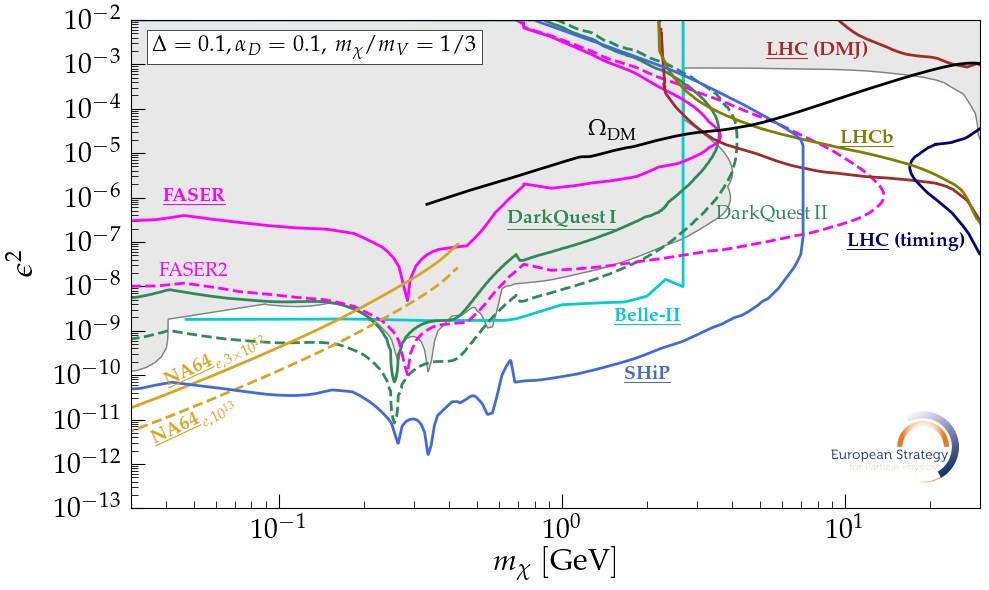

In [128]:
##### Input data files #####
## Sensitivity ##
df_Belle2 = pd.read_csv("Sensitivities/Sensitivities_InelasticDM_Belle-II.csv")
df_DarkQuest1 = pd.read_csv("Sensitivities/Sensitivities_InelasticDM_DarkQuest-Phase-I.csv")
df_DarkQuest2 = pd.read_csv("Sensitivities/Sensitivities_InelasticDM_DarkQuest-Phase-II.csv")
df_FASER = pd.read_csv("Sensitivities/Sensitivities_InelasticDM_FASER.csv")
df_FASER2 = pd.read_csv("Sensitivities/Sensitivities_InelasticDM_FASER2.csv")
df_LHCDMJ = pd.read_csv("Sensitivities/Sensitivities_InelasticDM_LHC-DMJ.csv")
df_LHCtiming = pd.read_csv("Sensitivities/Sensitivities_InelasticDM_LHC-timing.csv")
df_LHCb = pd.read_csv("Sensitivities/Sensitivities_InelasticDM_LHCb.csv")
df_NA64e3e12 = pd.read_csv("Sensitivities/Sensitivities_InelasticDM_NA64e-3e12.csv")
df_NA64e1e13 = pd.read_csv("Sensitivities/Sensitivities_InelasticDM_NA64e-1e13.csv")
df_SHiP = pd.read_csv("Sensitivities/Sensitivities_InelasticDM_SHiP.csv")
## Constraints ##
df_Const = pd.read_csv("Constraints-total.csv")

## Relic target ##
df_Relic = pd.read_csv("Relic-target-line.csv")
########################

##### Plot data files #####
fig = plt.figure()
fig.set_size_inches(10,6, forward=True)
ax = fig.add_subplot(1,1,1)
ax.tick_params(which='both',direction='in')
ax.tick_params(which='major',length=10)
ax.tick_params(which='minor',length=5)
ax.tick_params(labelsize=20, pad=7.5)
ax.set_xscale("log")
ax.set_yscale('log')
plt.xlim(3e-2,30)
plt.ylim(1e-13, 1e-2)
ax.yaxis.set_minor_locator(matplotlib.ticker.LogLocator(numticks=999, subs=np.linspace(2,9,8)))
ax.set_yticks(np.logspace(-13,-2,12))
plt.xlabel(r'$m_\chi~[\mathrm{GeV}]$',fontsize=22,loc='center',labelpad=0)
plt.ylabel(r'$\epsilon^2$',fontsize=22,loc='center',labelpad=10)
plt.text(0.025,0.935,r'$\Delta = 0.1, \alpha_D = 0.1,~m_\chi/m_V = 1/3$',fontsize=16,
         bbox=dict(facecolor='white', edgecolor='black',lw=0.5),transform=ax.transAxes)

## Constraint ##
plt.plot(df_Const['mass'],df_Const['coupling'], color='gray',lw=1)
plt.fill_between(df_Const['mass'],df_Const['coupling'], 1,color='lightgray',alpha=0.5)

## Sensitivity ##
plt.plot(df_Belle2['mass'],df_Belle2['coupling'],color=lcBelle2)
plt.plot(df_DarkQuest1['mass'],df_DarkQuest1['coupling'],color=lcDarkQuest)
plt.plot(df_DarkQuest2['mass'],df_DarkQuest2['coupling'],color=lcDarkQuest,ls='--')
plt.plot(df_FASER['mass'],df_FASER['coupling'],color=lcFASER)
plt.plot(df_FASER2['mass'],df_FASER2['coupling'],color=lcFASER,ls='--')
plt.plot(df_LHCDMJ['mass'],df_LHCDMJ['coupling'],color=lcLHCDMJ)
plt.plot(df_LHCtiming['mass'],df_LHCtiming['coupling'],color=lcLHCtiming)
plt.plot(df_LHCb['mass'],df_LHCb['coupling'],color=lcLHCb)
plt.plot(df_NA64e3e12['mass'],df_NA64e3e12['coupling'],color=lcNA64)
plt.plot(df_NA64e1e13['mass'],df_NA64e1e13['coupling'],color=lcNA64,ls='--')
plt.plot(df_SHiP['mass'],df_SHiP['coupling'],color=lcSHiP)

## Relic target ##
plt.plot(df_Relic['mass'],df_Relic['coupling'],color='black')

## Text for legends ##
plt.text(2.,2.e-9,r'{\bf \underline{Belle-II}}',fontsize=14,color=lcBelle2,ha='center',va='center')
plt.text(1.,3.2e-7,r'{\bf \underline{DarkQuest I}}',fontsize=14,color=lcDarkQuest,ha='center',va='center')
plt.text(5.5,4.e-7,r'{{DarkQuest II}}',fontsize=14,color=lcDarkQuest,ha='center',va='center')
plt.text(5.e-2,1.e-6,r'{\bf \underline{FASER}}',fontsize=14,color=lcFASER,ha='center',va='center')
plt.text(5.e-2,2.e-8,r'FASER2',fontsize=14,color=lcFASER,ha='center',va='center')
plt.text(8,2.e-3,r'{\bf \underline{LHC} (DMJ)}',fontsize=14,color=lcLHCDMJ,ha='center',va='center')
plt.text(16.5,1.e-7,r'{\bf \underline{LHC} (timing)}',fontsize=14,color=lcLHCtiming,ha='center',va='center')
plt.text(12,2.e-5,r'{\bf \underline{LHCb}}',fontsize=14,color=lcLHCb,ha='center',va='center')
plt.text(6e-2,2.e-10,r'{\bf \underline{NA64}$_{\,e,3\times 10^{12}}$',fontsize=14,
         rotation=25,color=lcNA64,ha='center',va='center')
plt.text(5e-2,8.e-12,r'{\bf \underline{NA64}$_{\,e,10^{13}}$',fontsize=14,
         rotation=25,color=lcNA64,ha='center',va='center')
plt.text(2,1.e-10,r'{\bf \underline{SHiP}}',fontsize=14,color=lcSHiP,ha='center',va='center')

plt.text(1.5,3e-5,r'$\Omega_\mathrm{DM}$',fontsize=16,color='black',ha='center',va='center')

## ESPPU logo ##
img = mpimg.imread("ESPP-logo-2025-color@3x.png")
inset_ax = ax.inset_axes([0.825, 0.05, 0.15, 0.15])  # x0, y0, 15% width & height
inset_ax.imshow(img)
inset_ax.axis('off')
#plt.text(6.e-1,2.e-14,r'{\bf ESPP 2026: Preliminary}',fontsize=16,rotation=0,color='black',ha='center',va='center')

#plt.legend(fontsize=14, loc = 'lower right')
plt.tight_layout()
plt.savefig('Plots/IneasticDM_lowmass.pdf',dpi=1000)

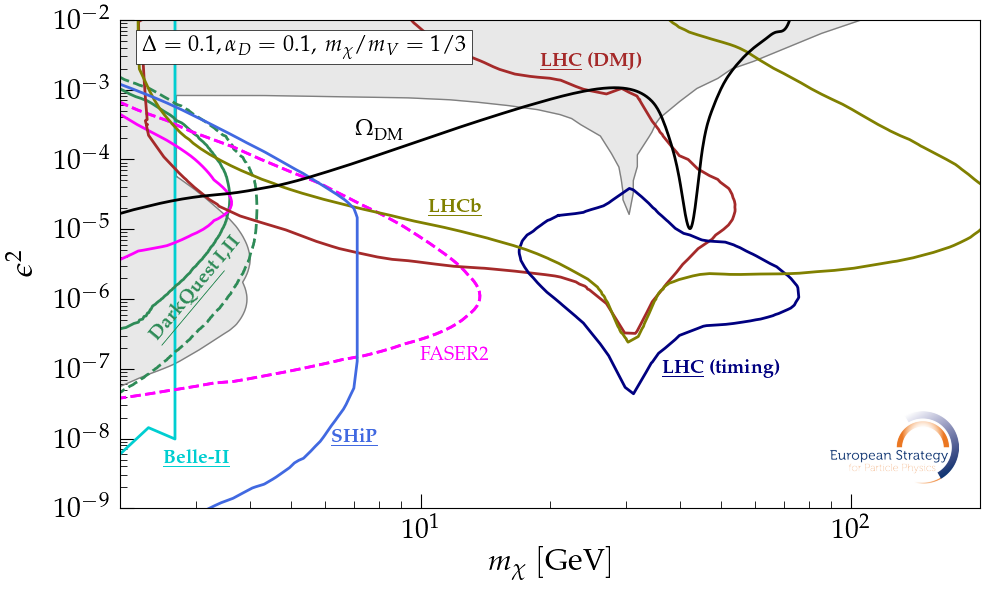

In [129]:
##### Input data files #####
## Sensitivity ##
df_Belle2 = pd.read_csv("Sensitivities/Sensitivities_InelasticDM_Belle-II.csv")
df_DarkQuest1 = pd.read_csv("Sensitivities/Sensitivities_InelasticDM_DarkQuest-Phase-I.csv")
df_DarkQuest2 = pd.read_csv("Sensitivities/Sensitivities_InelasticDM_DarkQuest-Phase-II.csv")
df_FASER = pd.read_csv("Sensitivities/Sensitivities_InelasticDM_FASER.csv")
df_FASER2 = pd.read_csv("Sensitivities/Sensitivities_InelasticDM_FASER2.csv")
df_LHCDMJ = pd.read_csv("Sensitivities/Sensitivities_InelasticDM_LHC-DMJ.csv")
df_LHCtiming = pd.read_csv("Sensitivities/Sensitivities_InelasticDM_LHC-timing.csv")
df_LHCb = pd.read_csv("Sensitivities/Sensitivities_InelasticDM_LHCb.csv")
df_NA64e3e12 = pd.read_csv("Sensitivities/Sensitivities_InelasticDM_NA64e-3e12.csv")
df_NA64e1e13 = pd.read_csv("Sensitivities/Sensitivities_InelasticDM_NA64e-1e13.csv")
df_SHiP = pd.read_csv("Sensitivities/Sensitivities_InelasticDM_SHiP.csv")
## Constraints ##
df_Const = pd.read_csv("Constraints-total.csv")

## Relic target ##
df_Relic = pd.read_csv("Relic-target-line.csv")
########################

##### Plot data files #####
fig = plt.figure()
fig.set_size_inches(10,6, forward=True)
ax = fig.add_subplot(1,1,1)
ax.tick_params(which='both',direction='in')
ax.tick_params(which='major',length=10)
ax.tick_params(which='minor',length=5)
ax.tick_params(labelsize=20, pad=7.5)
ax.set_xscale("log")
ax.set_yscale('log')
plt.xlim(2,2e2)
plt.ylim(1e-9, 1e-2)
ax.yaxis.set_minor_locator(matplotlib.ticker.LogLocator(numticks=999, subs=np.linspace(2,9,8)))
ax.set_yticks(np.logspace(-9,-2,8))
plt.xlabel(r'$m_\chi~[\mathrm{GeV}]$',fontsize=22,loc='center',labelpad=0)
plt.ylabel(r'$\epsilon^2$',fontsize=22,loc='center',labelpad=10)
plt.text(0.025,0.935,r'$\Delta = 0.1, \alpha_D = 0.1,~m_\chi/m_V = 1/3$',fontsize=16,
         bbox=dict(facecolor='white', edgecolor='black',lw=0.5),transform=ax.transAxes)

## Constraint ##
plt.plot(df_Const['mass'],df_Const['coupling'], color='gray',lw=1)
plt.fill_between(df_Const['mass'],df_Const['coupling'], 1,color='lightgray',alpha=0.5)

## Sensitivity ##
plt.plot(df_Belle2['mass'],df_Belle2['coupling'],color=lcBelle2)
plt.plot(df_DarkQuest1['mass'],df_DarkQuest1['coupling'],color=lcDarkQuest)
plt.plot(df_DarkQuest2['mass'],df_DarkQuest2['coupling'],color=lcDarkQuest,ls='--')
plt.plot(df_FASER['mass'],df_FASER['coupling'],color=lcFASER)
plt.plot(df_FASER2['mass'],df_FASER2['coupling'],color=lcFASER,ls='--')
plt.plot(df_FASER2['mass'],df_FASER2['coupling'],color=lcFASER,ls='--')
plt.plot(df_LHCDMJ['mass'],df_LHCDMJ['coupling'],color=lcLHCDMJ)
plt.plot(df_LHCtiming['mass'],df_LHCtiming['coupling'],color=lcLHCtiming)
plt.plot(df_LHCb['mass'],df_LHCb['coupling'],color=lcLHCb)
plt.plot(df_NA64e3e12['mass'],df_NA64e3e12['coupling'],color=lcNA64)
plt.plot(df_NA64e1e13['mass'],df_NA64e1e13['coupling'],color=lcNA64,ls='--')
plt.plot(df_SHiP['mass'],df_SHiP['coupling'],color=lcSHiP)

## Relic target ##
plt.plot(df_Relic['mass'],df_Relic['coupling'],color='black')

## Text for legends ##
plt.text(3.,5.e-9,r'{\bf \underline{Belle-II}}',fontsize=14,color=lcBelle2,ha='center',va='center')
plt.text(3.,1.35e-6,r'{\bf \underline{DarkQuest} I,II}',fontsize=14,rotation=50,color=lcDarkQuest,ha='center',va='center')
plt.text(12,1.5e-7,r'FASER2',fontsize=14,color=lcFASER,ha='center',va='center')
plt.text(25,2.5e-3,r'{\bf \underline{LHC} (DMJ)}',fontsize=14,color=lcLHCDMJ,ha='center',va='center')
plt.text(50,1.e-7,r'{\bf \underline{LHC} (timing)}',fontsize=14,color=lcLHCtiming,ha='center',va='center')
plt.text(12,2.e-5,r'{\bf \underline{LHCb}}',fontsize=14,color=lcLHCb,ha='center',va='center')
plt.text(7,1.e-8,r'{\bf \underline{SHiP}}',fontsize=14,color=lcSHiP,ha='center',va='center')

plt.text(8,2.5e-4,r'$\Omega_\mathrm{DM}$',fontsize=16,color='black',ha='center',va='center')

## ESPPU logo ##
img = mpimg.imread("ESPP-logo-2025-color@3x.png")
inset_ax = ax.inset_axes([0.825, 0.05, 0.15, 0.15])  # x0, y0, 15% width & height
inset_ax.imshow(img)
inset_ax.axis('off')
#plt.text(6.e-1,2.e-14,r'{\bf ESPP 2026: Preliminary}',fontsize=16,rotation=0,color='black',ha='center',va='center')

#plt.legend(fontsize=14, loc = 'lower right')
plt.tight_layout()
plt.savefig('Plots/IneasticDM_highmass.pdf',dpi=1000)